## PHASE 1 : ENTRAÎNEMENT INITIAL DU FSHMM

In [11]:
### Import des bibliothèques
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from hmm import GaussianFSHMM

In [12]:
# === 1. Charger ta base ===
df = pd.read_excel("C:/Users/Lenovo i7/OneDrive - ENSEA/Stage CGF Gestion/Documents/Mémoire/Data/EDOUARD/Rendement/rendements_portefeuilles_corr (1).xlsx", engine='openpyxl')

In [13]:
# === 2. Préparer les données ===
# S'assurer que les dates sont bien dans l'index (si tu as une colonne Date)
df.index = pd.to_datetime(df['Date'])  # si applicable
df = df.drop(columns=['Date'])         # si applicable

In [14]:
# Sélectionner les 1497 premières observations (jusqu’au 30/12/2022)
df_train = df.iloc[:2100].copy()

In [16]:
# === 3. Ajouter 2 variables bruitées ===
np.random.seed(42)
df_train['BRUIT_1'] = np.random.normal(0, 1, size=len(df_train))
df_train['BRUIT_2'] = np.random.normal(0, 1, size=len(df_train))



In [17]:
# === 4. Standardisation ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_train)


In [ ]:
# === 5. Entraînement du FSHMM ===
model = GaussianFSHMM(
    n_components=2,
    k=20,
    algorithm='viterbi',
    covariance_type='diag',
    init_params='stmc',
    n_iter=1000,
    random_state=42
)
model.fit(X_scaled)

,k,50


In [19]:
# === 6. Prédiction des régimes (bruts) ===
regimes = model.predict(X_scaled)
df_train['Regime'] = regimes

In [20]:
# === 7. Saliences (rho) ===
saliences = pd.Series(model.rho_, index=df_train.columns[:-1])  # toutes les variables sauf 'Regime'

# Affichage des résultats
print("✅ Régimes estimés (bruts) sur 1497 observations :")
print(df_train['Regime'].value_counts())
print("\n✅ Saliences (rho) estimées par FSHMM :")
print(saliences.sort_values(ascending=False))

✅ Régimes estimés (bruts) sur 1497 observations :
Regime
0    1323
1     777
Name: count, dtype: int64

✅ Saliences (rho) estimées par FSHMM :
Quality(ii) ROE                     0.494727
Value(ii) ResultNet-Cours           0.489029
Qaulity(iii) ROA                    0.469458
Liquidité(i) volume                 0.436991
Value (i)Booktomarket global        0.264666
Value(iii) CA-cours                 0.231215
Size(i) Capitalisation boursièr     0.215410
Growth(i) Divident yield            0.188604
BRUIT_2                             0.153952
Risk(i) Beta                        0.139018
Volatilité(i) la variance           0.113011
BRUIT_1                             0.103634
Mom(ii) 6 Month Price Momentum      0.071718
Momentum(i) Rendement Journalier    0.070223
Quality(i) Levier Financier         0.018465
dtype: float64


C:\Users\Lenovo i7\AppData\Local\Temp\ipykernel_14748\2777494570.py:13: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo i7\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


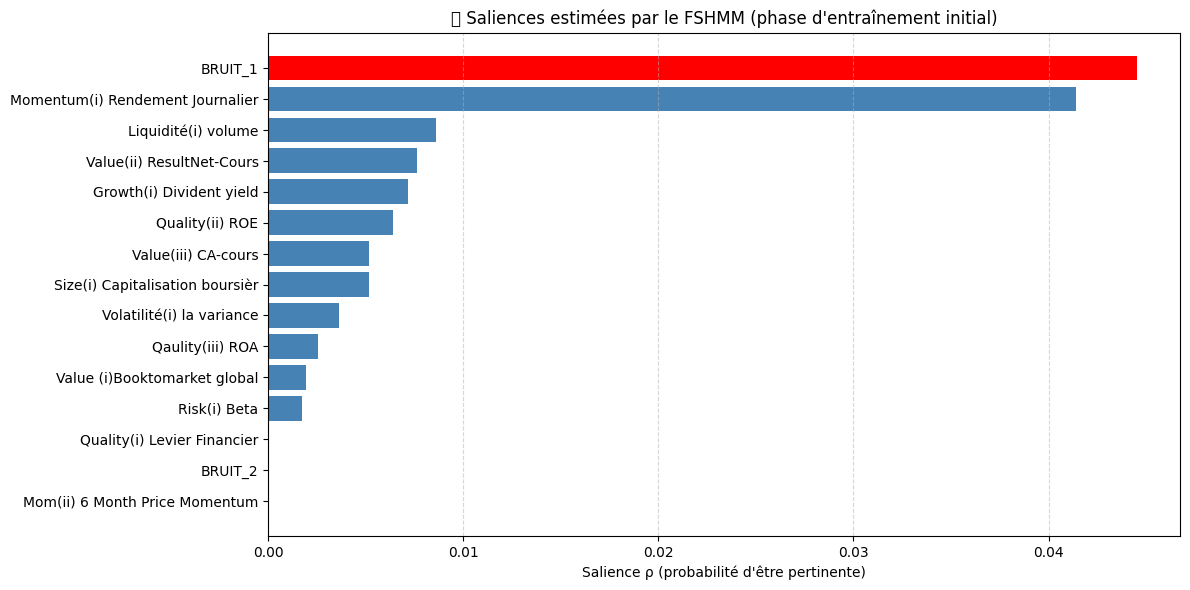

In [175]:
import matplotlib.pyplot as plt

# On suppose que 'saliences' est déjà un Series indexé par les noms de variables
saliences_sorted = saliences.sort_values(ascending=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(saliences_sorted.index, saliences_sorted.values, color=[
    'red' if 'BRUIT' in name else 'steelblue' for name in saliences_sorted.index
])
plt.xlabel("Salience ρ (probabilité d'être pertinente)")
plt.title("🎯 Saliences estimées par le FSHMM (phase d'entraînement initial)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [49]:
# Corrélation brute
#df_train.corr()['Qaulity(ii) ROA'].sort_values(ascending=False)


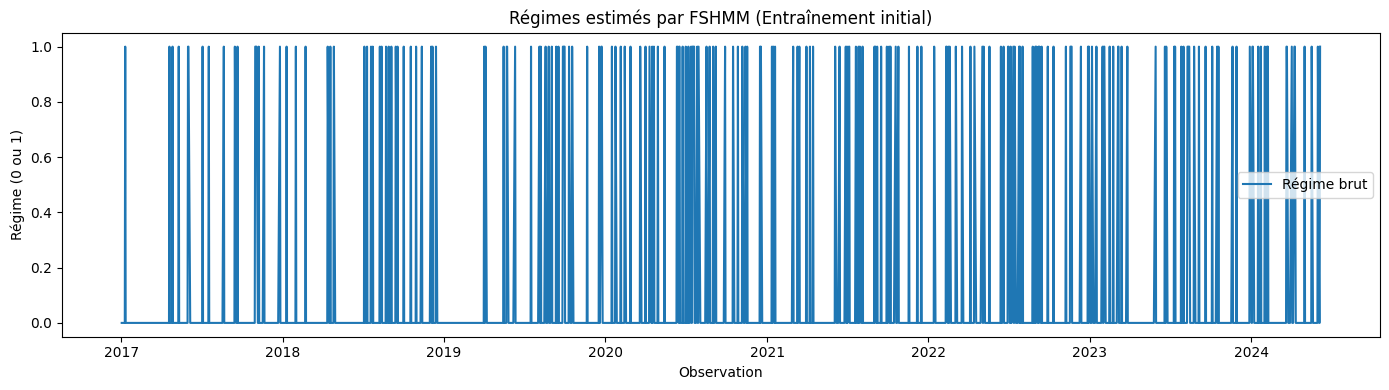

In [176]:
# Optionnel : visualisation
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df_train['Regime'], label='Régime brut')
plt.title("Régimes estimés par FSHMM (Entraînement initial)")
plt.xlabel("Observation")
plt.ylabel("Régime (0 ou 1)")
plt.legend()
plt.tight_layout()
plt.show()

## PHASE 2 : RÉENTRAÎNEMENT JOURNALIER

In [177]:
# Fenêtres
start_idx = 1853          # début du réentraînement (02/01/2023)
end_idx = 2107         # fin du réentraînement (30/12/2024)
dates = df.index

In [178]:
# Conteneurs de sortie
regimes_bruts = []
regimes_dates = []
facteurs_pertinents_par_jour = []

In [179]:
for t in range(start_idx, end_idx):
    df_train_t = df.iloc[:t].copy()

    # Ajouter 2 nouvelles variables bruitées
   # df_train_t['BRUIT_1'] = np.random.normal(0, 1, size=len(df_train_t))
   # df_train_t['BRUIT_2'] = np.random.normal(0, 1, size=len(df_train_t))

    # Standardisation
    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_train_t)

    # FSHMM
    model = GaussianFSHMM(
        n_components=2,
        k=450,
        algorithm='viterbi',
        covariance_type='diag',
        init_params='stmc',
        n_iter=200,
        random_state=42
    )
    model.fit(X_train)

    # Prédiction du régime pour l’observation courante t
    x_t = scaler.transform(df.iloc[[t]])
    r_t = model.predict(x_t)[0]
    
    # Sauvegarde
    regimes_bruts.append(r_t)
    regimes_dates.append(dates[t])

    # Sauvegarde des facteurs pertinents à t (rho > 0.5)çk
    var_names = df_train_t.columns
    rho = model.rho_
    
    pertinents = list(var_names[rho > 0.05])
    facteurs_pertinents_par_jour.append(pertinents)

    print(f"✓ Jour {t} / {end_idx} — Régime: {r_t}, facteurs pertinents: {pertinents}")


✓ Jour 1853 / 2107 — Régime: 1, facteurs pertinents: ['Value(ii) ResultNet-Cours', 'Quality(i) Levier Financier', 'Quality(ii) ROE', 'Qaulity(iii) ROA', 'Growth(i) Divident yield', 'Risk(i) Beta', 'Size(i) Capitalisation boursièr']
✓ Jour 1854 / 2107 — Régime: 0, facteurs pertinents: ['Value(ii) ResultNet-Cours', 'Quality(i) Levier Financier', 'Quality(ii) ROE', 'Qaulity(iii) ROA', 'Growth(i) Divident yield', 'Momentum(i) Rendement Journalier', 'Risk(i) Beta', 'Size(i) Capitalisation boursièr']
✓ Jour 1855 / 2107 — Régime: 1, facteurs pertinents: ['Value(ii) ResultNet-Cours', 'Quality(i) Levier Financier', 'Quality(ii) ROE', 'Qaulity(iii) ROA', 'Growth(i) Divident yield', 'Risk(i) Beta', 'Size(i) Capitalisation boursièr']
✓ Jour 1856 / 2107 — Régime: 1, facteurs pertinents: ['Value(ii) ResultNet-Cours', 'Quality(i) Levier Financier', 'Quality(ii) ROE', 'Qaulity(iii) ROA', 'Growth(i) Divident yield', 'Risk(i) Beta', 'Size(i) Capitalisation boursièr']
✓ Jour 1857 / 2107 — Régime: 1, fact

In [180]:
# Construction DataFrame final
#df_regimes_bruts = pd.DataFrame({
 #   'Date': regimes_dates,
  #  'Regime_bruit': regimes_bruts,
   # 'Facteurs_pertinents': facteurs_pertinents_par_jour
#})
#df_regimes_bruts.set_index('Date', inplace=True)

In [181]:
# Construction DataFrame final
df_regimes_bruts = pd.DataFrame({
    'Date': regimes_dates,
    'Regime_bruit': regimes_bruts,
    'Facteurs_pertinents': facteurs_pertinents_par_jour
})
df_regimes_bruts.set_index('Date', inplace=True)

In [182]:
print(len(regimes_dates))
print(len(regimes_bruts))
print(len(facteurs_pertinents_par_jour))


254
254
254


In [ ]:
# Trim regimes_dates and regimes_bruts to match the shortest list
regimes_dates = regimes_dates[:len(facteurs_pertinents_par_jour)]
regimes_bruts = regimes_bruts[:len(facteurs_pertinents_par_jour)]


In [121]:
# Construction DataFrame final
#df_regimes_bruts = pd.DataFrame({
#    'Date': regimes_dates,
#    'Regime_bruit': regimes_bruts,
#    'Facteurs_pertinents': facteurs_pertinents_par_jour
#})
#df_regimes_bruts.set_index('Date', inplace=True)

In [183]:
df_regimes_bruts

,Regime_bruit,Facteurs_pertinents
Date,,
2024-06-07,1,"[Value(ii) ResultNet-Cours, Quality(i) Levier ..."
2024-06-10,0,"[Value(ii) ResultNet-Cours, Quality(i) Levier ..."
2024-06-11,1,"[Value(ii) ResultNet-Cours, Quality(i) Levier ..."
2024-06-12,1,"[Value(ii) ResultNet-Cours, Quality(i) Levier ..."
2024-06-13,1,"[Value(ii) ResultNet-Cours, Quality(i) Levier ..."
...,...,...
2025-06-02,0,"[Value(ii) ResultNet-Cours, Liquidité(i) volum..."
2025-06-03,0,[Value(ii) ResultNet-Cours]
2025-06-04,0,[Value(ii) ResultNet-Cours]


In [184]:
import pandas as pd
import os

# Ton DataFrame déjà existant
# df_regimes_bruts = ...

# Chemin complet du fichier
chemin = r"C:\Users\Lenovo i7\OneDrive - ENSEA\Stage CGF Gestion\Documents\Mémoire\Python\regimes_bruts(5).xlsx"

# Sauvegarde en Excel
df_regimes_bruts.to_excel(chemin, index=False)

print(f"Fichier enregistré à : {chemin}")


Fichier enregistré à : C:\Users\Lenovo i7\OneDrive - ENSEA\Stage CGF Gestion\Documents\Mémoire\Python\regimes_bruts(5).xlsx


## PHASE 3 : GESTION DES RÉALLOCATIONS (allocation dynamique)

In [185]:
#Confirmation des régimes (d = 3)
def confirm_regime_change(regimes: list, d: int = 5):
    confirmed = []
    buffer = []
    
    for r in regimes:
        if not buffer or r == buffer[-1]:
            buffer.append(r)
        else:
            buffer = [r]
        
        if len(buffer) >= d:
            confirmed.append(r)
        elif confirmed:
            confirmed.append(confirmed[-1])  # maintenir l’ancien régime
        else:
            confirmed.append(r)  # au tout début
    return confirmed


In [186]:
# Application à la sortie de la phase 2 
regimes_bruts = df_regimes_bruts['Regime_bruit'].tolist()
regimes_confirmes = confirm_regime_change(regimes_bruts, d=3)
df_regimes_bruts['Regime_confirme'] = regimes_confirmes


In [187]:
regimes_confirmes

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [188]:
### Paramètres initiaux communs
# Période de test
test_start = 1853
test_end = 2107
dates_test = df.index[test_start:test_end]

In [189]:
len(dates_test)

254

In [190]:
# === Étape 2 : Régimes confirmés déjà obtenus ===
# df_regimes_bruts['Regime_confirme'] est disponible

# === ICI tu colles le code suivant : ===
debut_mois_idx = list(range(test_start, test_end, 22))
if debut_mois_idx[-1] != test_end - 1:
    debut_mois_idx.append(test_end - 1)
dates_debut_mois = df.index[debut_mois_idx]

reallocation_flags = []
for i, d in enumerate(dates_debut_mois):
    if i == 0:
        reallocation_flags.append(False)
        continue
    prev_window = df.index[debut_mois_idx[i-1]:debut_mois_idx[i]]
    changement = df_regimes_bruts.loc[prev_window, 'Regime_confirme'].diff().fillna(0) != 0
    reallocation_flags.append(changement.any())

df_regimes_bruts['Declencher_reallocation'] = False
for date, flag in zip(dates_debut_mois, reallocation_flags):
    df_regimes_bruts.loc[date, 'Declencher_reallocation'] = flag

# === Ensuite tu peux lancer les backtests ===


In [191]:
df_regimes_bruts

,Regime_bruit,Facteurs_pertinents,Regime_confirme,Declencher_reallocation
Date,,,,
2024-06-07,1,"[Value(ii) ResultNet-Cours, Quality(i) Levier ...",1,False
2024-06-10,0,"[Value(ii) ResultNet-Cours, Quality(i) Levier ...",1,False
2024-06-11,1,"[Value(ii) ResultNet-Cours, Quality(i) Levier ...",1,False
2024-06-12,1,"[Value(ii) ResultNet-Cours, Quality(i) Levier ...",1,False
2024-06-13,1,"[Value(ii) ResultNet-Cours, Quality(i) Levier ...",1,False
...,...,...,...,...
2025-06-02,0,"[Value(ii) ResultNet-Cours, Liquidité(i) volum...",0,False
2025-06-03,0,[Value(ii) ResultNet-Cours],0,False
2025-06-04,0,[Value(ii) ResultNet-Cours],0,False


In [192]:
df_regimes_bruts['Declencher_reallocation'].value_counts()

Declencher_reallocation
False    246
True       8
Name: count, dtype: int64

## Phase 4 : construction des 6 portefeuilles conditionnels au régime

In [193]:
import numpy as np
import cvxpy as cp

# === 1. Max Return (avec contrainte poids max = 80%) ===
def max_return_portfolio(mu, weight_max=0.8):
    n = len(mu)
    w = cp.Variable(n)
    objective = cp.Maximize(mu @ w)
    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= weight_max
    ]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return w.value


# === 2. Dynamique FSHMM ===
def dynamique_fshmm_portfolio(mu):
    n = len(mu)
    if np.all(mu > 0):
        w = mu / np.sum(mu)
    else:
        w = np.ones(n) / n
    return w

# === 3. Max Sharpe (avec taux sans risque à 0%) ===
def max_sharpe_portfolio(mu, cov, rf=0.0):
    n = len(mu)
    w = cp.Variable(n)
    excess_mu = mu - rf
    objective = cp.Maximize((excess_mu @ w) / cp.sqrt(cp.quad_form(w, cov)))
    constraints = [cp.sum(w) == 1, w >= 0]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return w.value

# === 4. Risk Parity ===
def risk_parity_portfolio(cov, max_iter=1000, tol=1e-8):
    n = cov.shape[0]
    w = np.ones(n) / n
    sigma = np.sqrt(np.diag(cov))
    V = cov

    for _ in range(max_iter):
        w_prev = w.copy()
        risk_contrib = w * (V @ w)
        total_risk = np.sqrt(w @ V @ w)
        risk_target = total_risk / n
        w *= risk_target / risk_contrib
        w /= np.sum(w)
        if np.linalg.norm(w - w_prev) < tol:
            break
    return w

# === 5. Max Diversification ===
def max_diversification_portfolio(mu, cov):
    sigma = np.sqrt(np.diag(cov))
    n = len(mu)
    w = cp.Variable(n)
    objective = cp.Maximize(w @ sigma / cp.sqrt(cp.quad_form(w, cov)))
    constraints = [cp.sum(w) == 1, w >= 0]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return w.value

# === 6. Minimum Variance ===
def min_variance_portfolio(cov):
    n = cov.shape[0]
    w = cp.Variable(n)
    objective = cp.Minimize(cp.quad_form(w, cov))
    constraints = [cp.sum(w) == 1, w >= 0]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return w.value


## PHASE 5 : Backtest dynamique des portefeuilles

In [194]:
## Foorcer l'unicité
df_regimes_bruts = df_regimes_bruts[~df_regimes_bruts.index.duplicated(keep='first')]


In [196]:
len(df_regimes_bruts)

252

### Portefeuille Max return

In [138]:
valeurs_maxreturn = [1.0]
rendements_maxreturn = []
poids_actuels = None
poids_mr_fshmm_dict = {}

for t in range(test_start, test_end):
    date = df.index[t]
    ligne = df_regimes_bruts.loc[date]
    rendements_journaliers = df.iloc[t]

    if ligne['Declencher_reallocation']:
        facteurs = ligne['Facteurs_pertinents']
        sous_df = df.loc[:date, facteurs]
        mu = sous_df.mean().values
        poids_actuels = max_return_portfolio(mu, weight_max=0.8)
        if poids_actuels is not None:
             poids_mr_fshmm_dict[date] = poids_actuels.copy()
        else:
            poids_mr_fshmm_dict[date] = None  # ou passer


    if poids_actuels is None:
        rendements_maxreturn.append(0)
        valeurs_maxreturn.append(valeurs_maxreturn[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers[facteurs].values
    rendements_maxreturn.append(rendement)
    valeurs_maxreturn.append(valeurs_maxreturn[-1] * (1 + rendement))

df_backtest_maxreturn = pd.DataFrame({
    'Date': dates_test,
    'Rendement': rendements_maxreturn,
    'Valeur': valeurs_maxreturn[1:]
}).set_index('Date')



ValueError: Invalid dimensions (0,).

In [195]:
poids_mr_fshmm_dict = {}  # Dictionnaire pour stocker les poids
rendements_mr_fshmm = []
valeurs_mr_fshmm = [1.0]

for t in range(1853, 2107):
    date = df.index[t]
    ligne = df_regimes_bruts.loc[date]
    rendements_journaliers = df.loc[date]

    if ligne['Declencher_reallocation']:
        facteurs = ligne['Facteurs_pertinents']

        # ✅ Vérifie si la liste de facteurs est vide
        if not facteurs:
            poids_actuels = None
        else:
            sous_df = df.loc[:date, facteurs]
            mu = sous_df.mean().values

            if len(mu) == 0:
                poids_actuels = None
            else:
                poids_actuels = max_return_portfolio(mu, weight_max=0.8)

        # Stocker les poids pour le jour de réallocation
        if poids_actuels is not None:
            poids_mr_fshmm_dict[date] = poids_actuels.copy()

    if poids_actuels is None:
        rendements_mr_fshmm.append(0)
        valeurs_mr_fshmm.append(valeurs_mr_fshmm[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers[poids_actuels != 0].values
    rendements_mr_fshmm.append(rendement)
    valeurs_mr_fshmm.append(valeurs_mr_fshmm[-1] * (1 + rendement))

# Construction du DataFrame final
df_backtest_maxreturn_fshmm = pd.DataFrame({
    'Date': df.index[1853:2107],
    'Rendement': rendements_mr_fshmm,
    'Valeur': valeurs_mr_fshmm[1:]
}).set_index('Date')


IndexError: Boolean index has wrong length: 2 instead of 13

In [139]:
len(dates_test)

253

In [48]:
poids_mr_fshmm_dict

{Timestamp('2024-07-10 00:00:00'): array([2.41641690e-08, 4.33815045e-08, 3.38114324e-08, 6.00382160e-08,
        2.88555594e-08, 5.08694109e-08, 1.99999861e-01, 7.99999898e-01]),
 Timestamp('2024-09-10 00:00:00'): array([2.71842711e-08, 4.81760921e-08, 3.82412797e-08, 6.48097282e-08,
        3.05313953e-08, 6.39858012e-08, 1.99999838e-01, 7.99999889e-01]),
 Timestamp('2024-12-13 00:00:00'): array([7.96861589e-07, 2.86317653e-07, 7.99991357e-01, 2.00007559e-01]),
 Timestamp('2025-01-16 00:00:00'): array([2.60891628e-07, 3.98943144e-07, 1.99999044e-01, 7.34970422e-07,
        7.99999561e-01]),
 Timestamp('2025-02-17 00:00:00'): array([1.91880252e-07, 2.67281652e-07, 1.99998994e-01, 8.68426799e-07,
        7.99999679e-01]),
 Timestamp('2025-03-17 00:00:00'): array([1.90389259e-07, 2.38668468e-07, 1.99995565e-01, 4.32739609e-06,
        7.99999679e-01]),
 Timestamp('2025-04-17 00:00:00'): array([3.17540206e-07, 1.99999788e-01, 7.99999894e-01])}

In [49]:
df_backtest_maxreturn

,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,0.001369,0.671070
2025-06-03,0.000491,0.671399
2025-06-04,0.001131,0.672158


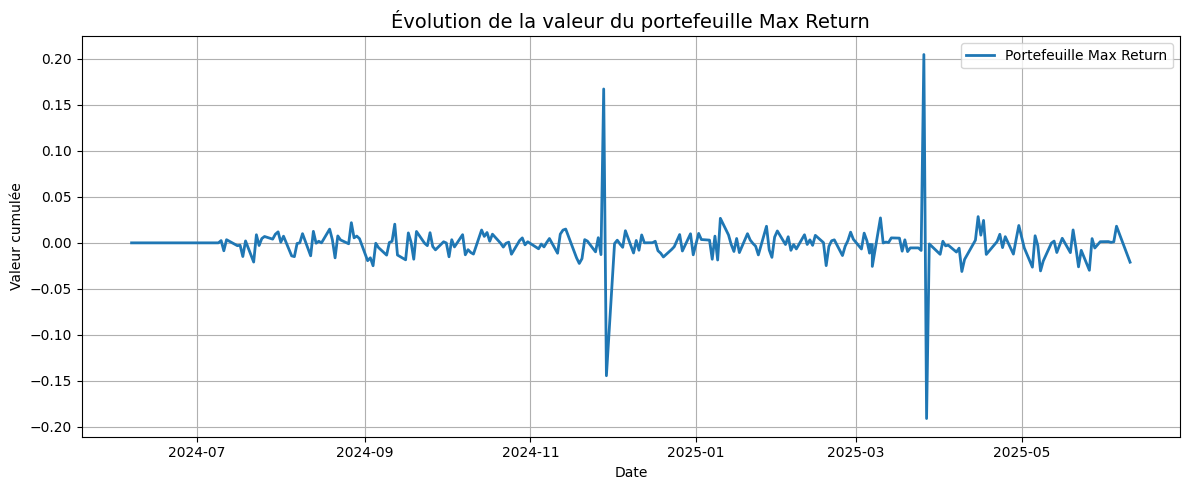

In [50]:
## Visualisation des rendements de Max return
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df_backtest_maxreturn['Rendement'], label='Portefeuille Max Return', linewidth=2)
plt.title("Évolution de la valeur du portefeuille Max Return", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Valeur cumulée")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Portefeuille Dyn

In [51]:
valeurs_dyn = [1.0]
rendements_dyn = []
poids_actuels = None

for t in range(test_start, test_end):
    date = df.index[t]
    ligne = df_regimes_bruts.loc[date]
    rendements_journaliers = df.iloc[t]

    if ligne['Declencher_reallocation']:
        facteurs = ligne['Facteurs_pertinents']
        mu = df.loc[:date, facteurs].mean().values
        poids_actuels = dynamique_fshmm_portfolio(mu)

    if poids_actuels is None:
        rendements_dyn.append(0)
        valeurs_dyn.append(valeurs_dyn[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers[facteurs].values
    rendements_dyn.append(rendement)
    valeurs_dyn.append(valeurs_dyn[-1] * (1 + rendement))

df_backtest_dyn = pd.DataFrame({
    'Date': dates_test,
    'Rendement': rendements_dyn,
    'Valeur': valeurs_dyn[1:]
}).set_index('Date')


In [143]:
facteurs, poids_dyn_fshmm_dict, nouveaux_poids

(['Value(ii) ResultNet-Cours',
  'Quality(i) ROE',
  'Qaulity(ii) ROA',
  'Growth(i) Divident yield',
  'Liquidité(i) volume',
  'Size(i) Capitalisation boursièr'],
 {Timestamp('2024-05-06 00:00:00'): array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
         0.16666667]),
  Timestamp('2024-05-10 00:00:00'): array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
         0.16666667]),
  Timestamp('2024-05-13 00:00:00'): array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
         0.16666667]),
  Timestamp('2024-05-20 00:00:00'): array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
         0.16666667]),
  Timestamp('2024-05-27 00:00:00'): array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
         0.16666667]),
  Timestamp('2024-06-03 00:00:00'): array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
         0.16666667]),
  Timestamp('2024-06-10 00:00:00'): array([0.16666667, 0.16666667, 0.16666667, 

In [53]:
df_backtest_dyn


,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,0.001348,0.720664
2025-06-03,0.000269,0.720858
2025-06-04,0.006307,0.725405


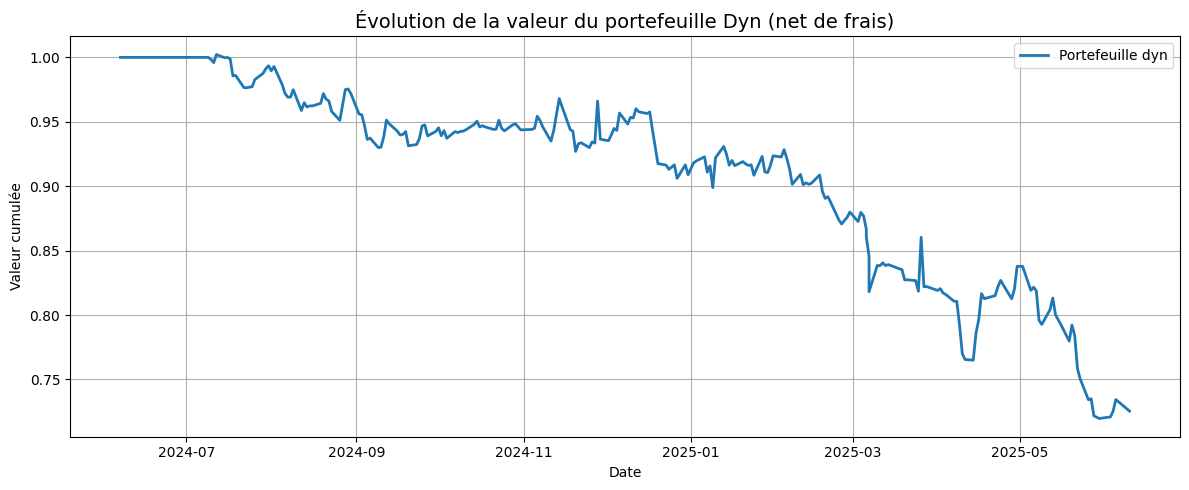

In [37]:
## Visualisation des rendements de Dyn
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df_backtest_dyn['Valeur'], label='Portefeuille dyn', linewidth=2)
plt.title("Évolution de la valeur du portefeuille Dyn (net de frais)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Valeur cumulée")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Portefeuille Max Sharpe

In [45]:
# === Initialisation ===
valeurs_sharpe = [1.0]
rendements_sharpe = []
poids_actuels_sharpe = None
nb_realloc_sharpe = 0

for i, t in enumerate(range(test_start, test_end)):
    date = df.index[t]
    ligne = df_regimes_bruts.loc[date]
    rendements_journaliers = df.iloc[t]

    # Réallocation ?
    if ligne['Declencher_reallocation']:
        nb_realloc_sharpe += 1
        facteurs = ligne['Facteurs_pertinents']
        regime = ligne['Regime_confirme']

        # Sous-échantillon pour estimer mu et covariance
        sous_df = df.loc[:date, facteurs]
        mu = sous_df.mean().values
        cov = sous_df.cov().values

        # Calcul des nouveaux poids Max Sharpe
        try:
            nouveaux_poids = max_sharpe_portfolio(mu, cov, rf=0.0)
        except:
            nouveaux_poids = np.ones(len(mu)) / len(mu)  # fallback équipondéré

        # Frais de transaction
        if poids_actuels_sharpe is not None:
            frais = c * np.sum(np.abs(nouveaux_poids - poids_actuels_sharpe))
        else:
            frais = 0
        poids_actuels_sharpe = nouveaux_poids

    elif poids_actuels_sharpe is not None:
        frais = 0
    else:
        rendements_sharpe.append(0)
        valeurs_sharpe.append(valeurs_sharpe[-1])
        continue

    # Rendement net du jour
    rendements_factors = rendements_journaliers[facteurs].values
    rendement_net = poids_actuels_sharpe @ rendements_factors - frais
    rendements_sharpe.append(rendement_net)

    # Valeur cumulée
    nouvelles_valeurs = valeurs_sharpe[-1] * (1 + rendement_net)
    valeurs_sharpe.append(nouvelles_valeurs)

# Résultat final
df_backtest_sharpe = pd.DataFrame({
    'Date': dates_test,
    'Rendement': rendements_sharpe,
    'Valeur': valeurs_sharpe[1:]
}).set_index('Date')


In [54]:
def max_sharpe_portfolio(mu, cov, rf=0.0):
    excess_returns = mu - rf
    inv_cov = np.linalg.pinv(cov)
    w = inv_cov @ excess_returns
    w = np.maximum(w, 0)  # pas de short

    if np.sum(w) == 0 or np.any(np.isnan(w)):
        w = np.ones_like(mu) / len(mu)  # fallback: équipondéré
    else:
        w /= np.sum(w)

    return w


valeurs_sharpe = [1.0]
rendements_sharpe = []
poids_actuels = None

for t in range(test_start, test_end):
    date = df.index[t]
    ligne = df_regimes_bruts.loc[date]
    rendements_journaliers = df.iloc[t]

    if ligne['Declencher_reallocation']:
        facteurs = ligne['Facteurs_pertinents']
        sous_df = df.loc[:date, facteurs]
        mu = sous_df.mean().values
        cov = sous_df.cov().values
        poids_actuels = max_sharpe_portfolio(mu, cov, rf=0.0)

    if poids_actuels is None:
        rendements_sharpe.append(0)
        valeurs_sharpe.append(valeurs_sharpe[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers[facteurs].values
    rendements_sharpe.append(rendement)
    valeurs_sharpe.append(valeurs_sharpe[-1] * (1 + rendement))

df_backtest_sharpe = pd.DataFrame({
    'Date': dates_test,
    'Rendement': rendements_sharpe,
    'Valeur': valeurs_sharpe[1:]
}).set_index('Date')


In [55]:
df_backtest_sharpe

,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,0.001348,0.682958
2025-06-03,0.000269,0.683142
2025-06-04,0.006307,0.687451


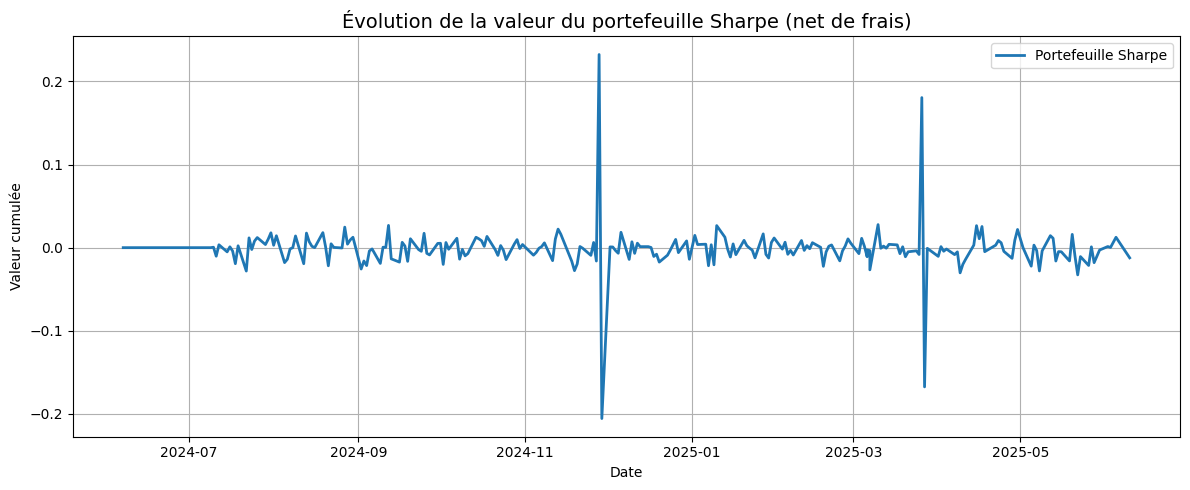

In [56]:
## Visualisation des rendements de Max Sharpe
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df_backtest_sharpe['Rendement'], label='Portefeuille Sharpe', linewidth=2)
plt.title("Évolution de la valeur du portefeuille Sharpe (net de frais)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Valeur cumulée")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Portefeuille Risk Parity

In [57]:
# === Initialisation ===
valeurs_rp = [1.0]
rendements_rp = []
poids_actuels_rp = None
nb_realloc_rp = 0

for i, t in enumerate(range(test_start, test_end)):
    date = df.index[t]
    ligne = df_regimes_bruts.loc[date]
    rendements_journaliers = df.iloc[t]

    # Réallocation ?
    if ligne['Declencher_reallocation']:
        nb_realloc_rp += 1
        facteurs = ligne['Facteurs_pertinents']
        regime = ligne['Regime_confirme']

        sous_df = df.loc[:date, facteurs]
        cov = sous_df.cov().values

        try:
            nouveaux_poids = risk_parity_portfolio(cov)
        except:
            nouveaux_poids = np.ones(len(cov)) / len(cov)

        if poids_actuels_rp is not None:
            frais = c * np.sum(np.abs(nouveaux_poids - poids_actuels_rp))
        else:
            frais = 0
        poids_actuels_rp = nouveaux_poids

    elif poids_actuels_rp is not None:
        frais = 0
    else:
        rendements_rp.append(0)
        valeurs_rp.append(valeurs_rp[-1])
        continue

    # Rendement net
    rendements_factors = rendements_journaliers[facteurs].values
    rendement_net = poids_actuels_rp @ rendements_factors - frais
    rendements_rp.append(rendement_net)

    # Valeur cumulée
    nouvelles_valeurs = valeurs_rp[-1] * (1 + rendement_net)
    valeurs_rp.append(nouvelles_valeurs)

# Résultat final
df_backtest_rp = pd.DataFrame({
    'Date': dates_test,
    'Rendement': rendements_rp,
    'Valeur': valeurs_rp[1:]
}).set_index('Date')


NameError: name 'c' is not defined

In [58]:
valeurs_rp = [1.0]
rendements_rp = []
poids_actuels = None

for t in range(test_start, test_end):
    date = df.index[t]
    ligne = df_regimes_bruts.loc[date]
    rendements_journaliers = df.iloc[t]

    if ligne['Declencher_reallocation']:
        facteurs = ligne['Facteurs_pertinents']
        cov = df.loc[:date, facteurs].cov().values
        poids_actuels = risk_parity_portfolio(cov)

    if poids_actuels is None:
        rendements_rp.append(0)
        valeurs_rp.append(valeurs_rp[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers[facteurs].values
    rendements_rp.append(rendement)
    valeurs_rp.append(valeurs_rp[-1] * (1 + rendement))

df_backtest_rp = pd.DataFrame({
    'Date': dates_test,
    'Rendement': rendements_rp,
    'Valeur': valeurs_rp[1:]
}).set_index('Date')


In [59]:
df_backtest_rp

,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,0.001349,0.715992
2025-06-03,0.000289,0.716199
2025-06-04,0.005846,0.720386


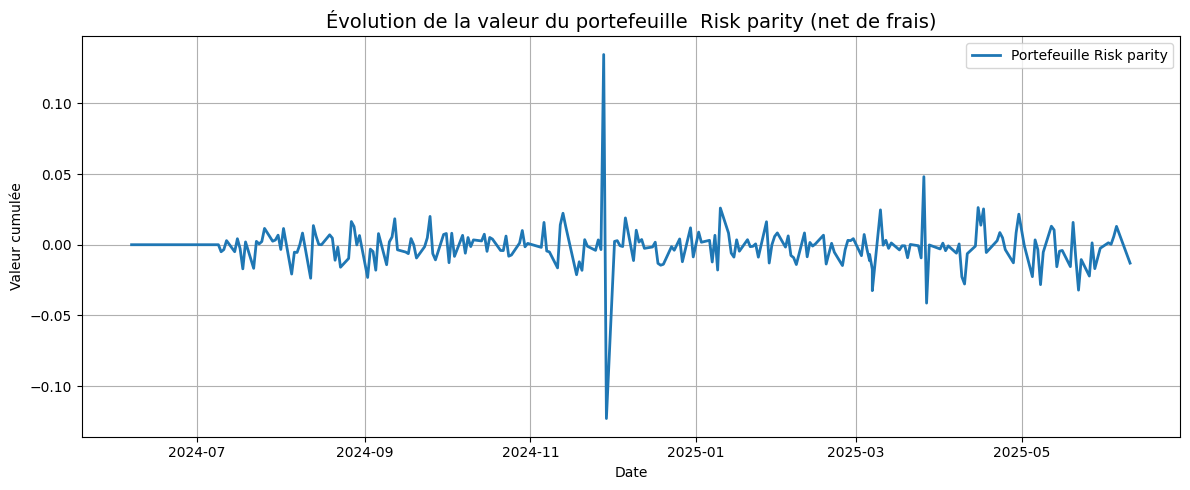

In [43]:
## Visualisation des rendements de Max Sharpe
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df_backtest_rp['Rendement'], label='Portefeuille Risk parity', linewidth=2)
plt.title("Évolution de la valeur du portefeuille  Risk parity (net de frais)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Valeur cumulée")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Portefeuille Max Diversification

In [60]:
def max_diversification_portfolio(mu, cov):
    sigma = np.sqrt(np.diag(cov))
    inv_vol = 1 / sigma
    w = inv_vol / np.sum(inv_vol)
    return w

valeurs_div = [1.0]
rendements_div = []
poids_actuels = None

for t in range(test_start, test_end):
    date = df.index[t]
    ligne = df_regimes_bruts.loc[date]
    rendements_journaliers = df.iloc[t]

    if ligne['Declencher_reallocation']:
        facteurs = ligne['Facteurs_pertinents']
        sous_df = df.loc[:date, facteurs]
        mu = sous_df.mean().values
        cov = sous_df.cov().values
        poids_actuels = max_diversification_portfolio(mu, cov)

    if poids_actuels is None:
        rendements_div.append(0)
        valeurs_div.append(valeurs_div[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers[facteurs].values
    rendements_div.append(rendement)
    valeurs_div.append(valeurs_div[-1] * (1 + rendement))

df_backtest_div = pd.DataFrame({
    'Date': dates_test,
    'Rendement': rendements_div,
    'Valeur': valeurs_div[1:]
}).set_index('Date')


In [61]:
df_backtest_div

,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,0.001393,0.718953
2025-06-03,0.000277,0.719152
2025-06-04,0.006134,0.723564


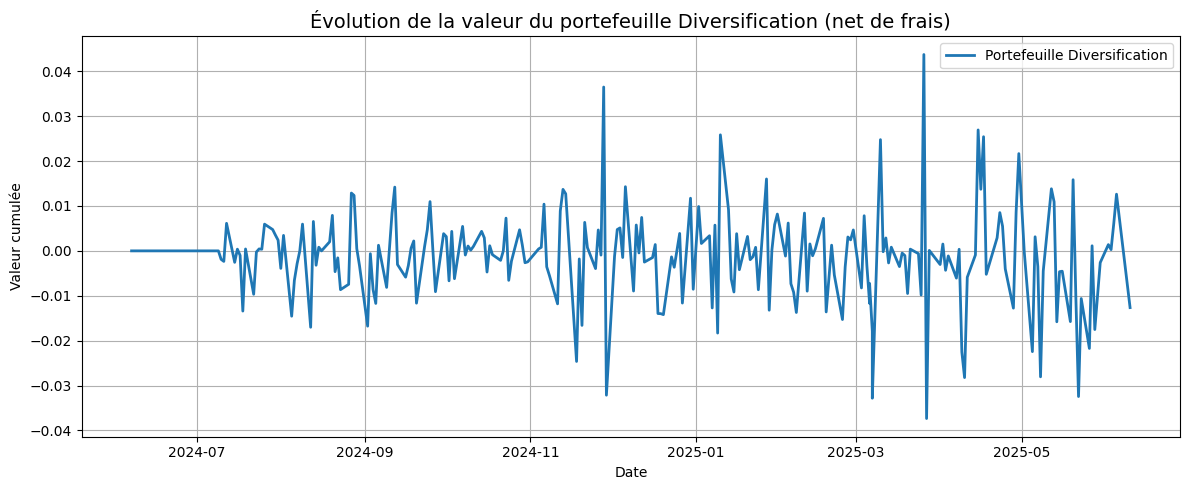

In [46]:
## Visualisation des rendements de Max Sharpe
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df_backtest_div['Rendement'], label='Portefeuille Diversification', linewidth=2)
plt.title("Évolution de la valeur du portefeuille Diversification (net de frais)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Valeur cumulée")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Portefeuille Minimum Variance

In [47]:
# === Initialisation ===
valeurs_minvar = [1.0]
rendements_minvar = []
poids_actuels_minvar = None
nb_realloc_minvar = 0

for i, t in enumerate(range(test_start, test_end)):
    date = df.index[t]
    ligne = df_regimes_bruts.loc[date]
    rendements_journaliers = df.iloc[t]

    # Réallocation ?
    if ligne['Declencher_reallocation']:
        nb_realloc_minvar += 1
        facteurs = ligne['Facteurs_pertinents']
        regime = ligne['Regime_confirme']

        sous_df = df.loc[:date, facteurs]
        cov = sous_df.cov().values

        try:
            nouveaux_poids = min_variance_portfolio(cov)
        except:
            nouveaux_poids = np.ones(len(cov)) / len(cov)

        if poids_actuels_minvar is not None:
            frais = c * np.sum(np.abs(nouveaux_poids - poids_actuels_minvar))
        else:
            frais = 0
        poids_actuels_minvar = nouveaux_poids

    elif poids_actuels_minvar is not None:
        frais = 0
    else:
        rendements_minvar.append(0)
        valeurs_minvar.append(valeurs_minvar[-1])
        continue

    # Rendement net
    rendements_factors = rendements_journaliers[facteurs].values
    rendement_net = poids_actuels_minvar @ rendements_factors - frais
    rendements_minvar.append(rendement_net)

    # Valeur cumulée
    nouvelles_valeurs = valeurs_minvar[-1] * (1 + rendement_net)
    valeurs_minvar.append(nouvelles_valeurs)

# Résultat final
df_backtest_minvar = pd.DataFrame({
    'Date': dates_test,
    'Rendement': rendements_minvar,
    'Valeur': valeurs_minvar[1:]
}).set_index('Date')


NameError: name 'c' is not defined

In [62]:
valeurs_minvar = [1.0]
rendements_minvar = []
poids_actuels = None

for t in range(test_start, test_end):
    date = df.index[t]
    ligne = df_regimes_bruts.loc[date]
    rendements_journaliers = df.iloc[t]

    if ligne['Declencher_reallocation']:
        facteurs = ligne['Facteurs_pertinents']
        cov = df.loc[:date, facteurs].cov().values
        poids_actuels = min_variance_portfolio(cov)

    if poids_actuels is None:
        rendements_minvar.append(0)
        valeurs_minvar.append(valeurs_minvar[-1])
        continue

    rendement = poids_actuels @ rendements_journaliers[facteurs].values
    rendements_minvar.append(rendement)
    valeurs_minvar.append(valeurs_minvar[-1] * (1 + rendement))

df_backtest_minvar = pd.DataFrame({
    'Date': dates_test,
    'Rendement': rendements_minvar,
    'Valeur': valeurs_minvar[1:]
}).set_index('Date')


In [63]:
df_backtest_minvar

,Rendement,Valeur
Date,,
2024-06-07,0.000000,1.000000
2024-06-10,0.000000,1.000000
2024-06-11,0.000000,1.000000
2024-06-12,0.000000,1.000000
2024-06-13,0.000000,1.000000
...,...,...
2025-06-02,0.001088,0.702403
2025-06-03,0.000350,0.702648
2025-06-04,0.004307,0.705674


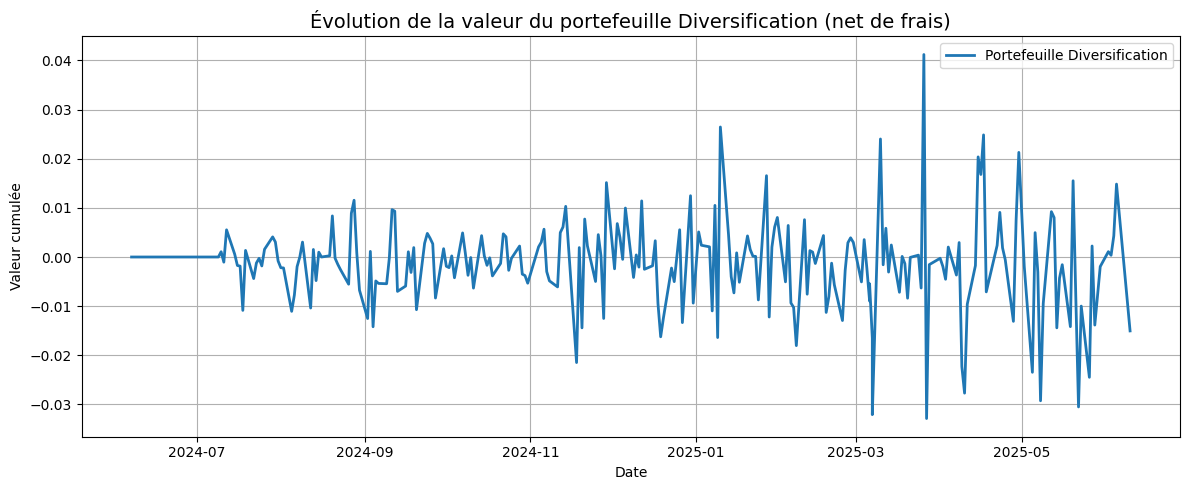

In [50]:
## Visualisation des rendements de Max Sharpe
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df_backtest_minvar['Rendement'], label='Portefeuille Diversification', linewidth=2)
plt.title("Évolution de la valeur du portefeuille Diversification (net de frais)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Valeur cumulée")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Analyse comparative

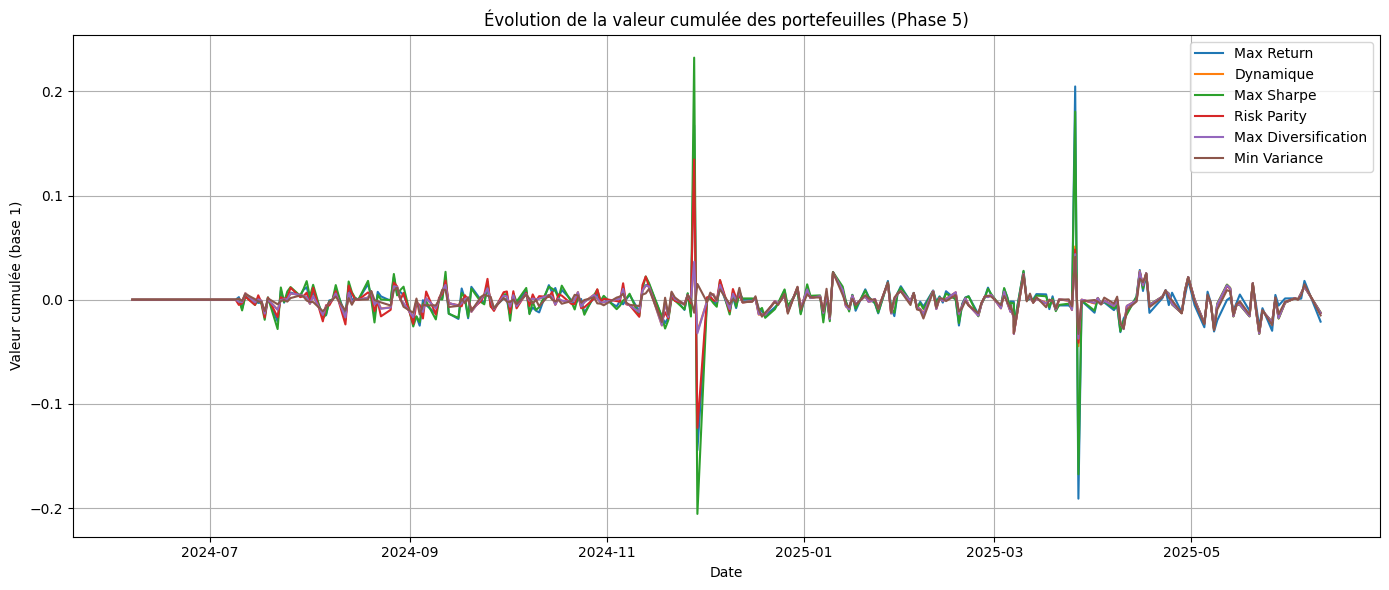

In [64]:
import matplotlib.pyplot as plt

# Supposons que les DataFrames suivants sont déjà construits et contiennent la colonne "Valeur" :
# df_backtest_maxreturn, df_backtest_dyn, df_backtest_sharpe,
# df_backtest_rp, df_backtest_div, df_backtest_minvar

plt.figure(figsize=(14, 6))

plt.plot(df_backtest_maxreturn['Rendement'], label='Max Return')
plt.plot(df_backtest_dyn['Rendement'], label='Dynamique')
plt.plot(df_backtest_sharpe['Rendement'], label='Max Sharpe')
plt.plot(df_backtest_rp['Rendement'], label='Risk Parity')
plt.plot(df_backtest_div['Rendement'], label='Max Diversification')
plt.plot(df_backtest_minvar['Rendement'], label='Min Variance')

plt.title("Évolution de la valeur cumulée des portefeuilles (Phase 5)")
plt.xlabel("Date")
plt.ylabel("Valeur cumulée (base 1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# CONSTRUCTION DES BENCHMARK

## Benchmarks des 6 portefeuilles

In [65]:
# Extraire les dates journalières de la période de test
dates_test = df.index[test_start:test_end]

# Créer un DataFrame temporaire pour grouper par mois
df_temp = pd.DataFrame(index=dates_test)
df_temp["mois"] = df_temp.index.to_period("M")

# Obtenir les 1ers jours ouvrés de chaque mois
dates_rebalancement = df_temp.groupby("mois").apply(lambda x: x.index[0]).to_list()

# Obtenir tous les facteurs 
facteurs_totaux = df.columns.tolist()

C:\Users\Lenovo i7\AppData\Local\Temp\ipykernel_14748\621615938.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dates_rebalancement = df_temp.groupby("mois").apply(lambda x: x.index[0]).to_list()


In [66]:
## Initialiser les dictionnaires de performance
benchmarks = {
    "Dyn": [],
    "Sharpe": [],
    "MaxReturn": [],
    "MinVar": [],
    "MaxDiv": [],
    "RiskParity": []
}

valeurs_init = {k: [1.0] for k in benchmarks}
poids_actuels = {k: None for k in benchmarks}


### Portefeuille dyn bench

In [67]:
# === Initialisation Dyn Bench ===

valeurs_dyn_bench = [1.0]
rendements_dyn_bench = []
poids_dyn_bench = None
dates_dyn_bench = []

# Boucle sur la période de test
for t in range(test_start, test_end):
    date = df.index[t]
    rendements_factors = df.iloc[t][facteurs_totaux].values  # tous les facteurs globaux
    dates_dyn_bench.append(date)

    # Réallocation mensuelle ?
    if date in dates_rebalancement:
        sous_df = df.iloc[:t][facteurs_totaux]
        mu = sous_df.mean().values

        if np.all(mu > 0):
            poids_dyn_bench = mu / np.sum(mu)
        else:
            poids_dyn_bench = np.ones(len(mu)) / len(mu)

    if poids_dyn_bench is None:
        rendement_net = 0
    else:
        rendement_net = poids_dyn_bench @ rendements_factors

    rendements_dyn_bench.append(rendement_net)
    valeurs_dyn_bench.append(valeurs_dyn_bench[-1] * (1 + rendement_net))

# Résultat final
df_bench_dyn = pd.DataFrame({
    'Date': dates_dyn_bench,
    'Rendement': rendements_dyn_bench,
    'Valeur': valeurs_dyn_bench[1:]
}).set_index('Date')


In [68]:
df_bench_dyn

,Rendement,Valeur
Date,,
2024-06-07,0.005066,1.005066
2024-06-10,0.000771,1.005841
2024-06-11,-0.004511,1.001303
2024-06-12,-0.003774,0.997524
2024-06-13,-0.006986,0.990556
...,...,...
2025-06-02,0.004812,0.856658
2025-06-03,-0.001877,0.855050
2025-06-04,0.003139,0.857735


### Benchmark Sharpe

In [69]:
from numpy.linalg import inv

# === Initialisation Sharpe Bench ===

valeurs_sharpe_bench = [1.0]
rendements_sharpe_bench = []
poids_sharpe_bench = None
dates_sharpe_bench = []

# Boucle sur la période de test
for t in range(test_start, test_end):
    date = df.index[t]
    rendements_factors = df.iloc[t][facteurs_totaux].values  # tous les facteurs
    dates_sharpe_bench.append(date)

    # Réallocation mensuelle ?
    if date in dates_rebalancement:
        sous_df = df.iloc[:t][facteurs_totaux]
        mu = sous_df.mean().values
        sigma = sous_df.cov().values

        try:
            inv_sigma = inv(sigma)
            poids_sharpe_bench = inv_sigma @ mu
            poids_sharpe_bench = poids_sharpe_bench / np.sum(poids_sharpe_bench)
            poids_sharpe_bench = np.maximum(poids_sharpe_bench, 0)  # no short
            poids_sharpe_bench = poids_sharpe_bench / np.sum(poids_sharpe_bench)
        except:
            poids_sharpe_bench = np.ones(len(mu)) / len(mu)

    if poids_sharpe_bench is None:
        rendement_net = 0
    else:
        rendement_net = poids_sharpe_bench @ rendements_factors

    rendements_sharpe_bench.append(rendement_net)
    valeurs_sharpe_bench.append(valeurs_sharpe_bench[-1] * (1 + rendement_net))

# Résultat final
df_bench_sharpe = pd.DataFrame({
    'Date': dates_sharpe_bench,
    'Rendement': rendements_sharpe_bench,
    'Valeur': valeurs_sharpe_bench[1:]
}).set_index('Date')


In [70]:
df_bench_sharpe

,Rendement,Valeur
Date,,
2024-06-07,0.008574,1.008574
2024-06-10,0.002107,1.010699
2024-06-11,-0.007991,1.002623
2024-06-12,-0.004583,0.998028
2024-06-13,-0.010892,0.987158
...,...,...
2025-06-02,-0.008501,0.743258
2025-06-03,-0.003372,0.740751
2025-06-04,-0.000198,0.740605


### Max return bench

In [71]:
from scipy.optimize import minimize

# === Initialisation MR Bench ===

valeurs_mr_bench = [1.0]
rendements_mr_bench = []
poids_mr_bench = None
dates_mr_bench = []

# Fonction objectif à minimiser (donc on prend le négatif du rendement)
def objectif_neg_return(w, mu):
    return -w @ mu

# Contrainte : somme des poids = 1
def contrainte_somme(w):
    return np.sum(w) - 1

# Boucle sur la période de test
for t in range(test_start, test_end):
    date = df.index[t]
    rendements_factors = df.iloc[t][facteurs_totaux].values
    dates_mr_bench.append(date)

    if date in dates_rebalancement:
        sous_df = df.iloc[:t][facteurs_totaux]
        mu = sous_df.mean().values
        N = len(mu)

        w0 = np.ones(N) / N
        bounds = [(0, 0.8) for _ in range(N)]
        contraintes = {'type': 'eq', 'fun': contrainte_somme}

        res = minimize(objectif_neg_return, w0, args=(mu,), bounds=bounds, constraints=contraintes)
        poids_mr_bench = res.x if res.success else w0

    rendement_net = poids_mr_bench @ rendements_factors if poids_mr_bench is not None else 0
    rendements_mr_bench.append(rendement_net)
    valeurs_mr_bench.append(valeurs_mr_bench[-1] * (1 + rendement_net))

# Résultat final
df_bench_mr = pd.DataFrame({
    'Date': dates_mr_bench,
    'Rendement': rendements_mr_bench,
    'Valeur': valeurs_mr_bench[1:]
}).set_index('Date')


In [72]:
df_bench_mr

,Rendement,Valeur
Date,,
2024-06-07,0.002504,1.002504
2024-06-10,-0.010390,0.992088
2024-06-11,-0.003274,0.988840
2024-06-12,-0.003379,0.985498
2024-06-13,-0.003236,0.982309
...,...,...
2025-06-02,0.058556,1.919298
2025-06-03,0.000793,1.920821
2025-06-04,0.015785,1.951141


### Min Var Bench

In [73]:
# === Initialisation MV Bench ===

valeurs_mv_bench = [1.0]
rendements_mv_bench = []
poids_mv_bench = None
dates_mv_bench = []

# Fonction objectif : variance = w' Σ w
def objectif_variance(w, sigma):
    return w.T @ sigma @ w

# Contrainte : somme des poids = 1
def contrainte_somme(w):
    return np.sum(w) - 1

# Boucle sur la période de test
for t in range(test_start, test_end):
    date = df.index[t]
    rendements_factors = df.iloc[t][facteurs_totaux].values
    dates_mv_bench.append(date)

    if date in dates_rebalancement:
        sous_df = df.iloc[:t][facteurs_totaux]
        sigma = sous_df.cov().values
        N = len(facteurs_totaux)

        w0 = np.ones(N) / N
        bounds = [(0, 1) for _ in range(N)]
        contraintes = {'type': 'eq', 'fun': contrainte_somme}

        res = minimize(objectif_variance, w0, args=(sigma,), bounds=bounds, constraints=contraintes)
        poids_mv_bench = res.x if res.success else w0

    rendement_net = poids_mv_bench @ rendements_factors if poids_mv_bench is not None else 0
    rendements_mv_bench.append(rendement_net)
    valeurs_mv_bench.append(valeurs_mv_bench[-1] * (1 + rendement_net))

# Résultat final
df_bench_mv = pd.DataFrame({
    'Date': dates_mv_bench,
    'Rendement': rendements_mv_bench,
    'Valeur': valeurs_mv_bench[1:]
}).set_index('Date')


In [74]:
df_bench_mv

,Rendement,Valeur
Date,,
2024-06-07,0.005066,1.005066
2024-06-10,0.000771,1.005841
2024-06-11,-0.004511,1.001303
2024-06-12,-0.003774,0.997524
2024-06-13,-0.006986,0.990556
...,...,...
2025-06-02,0.004812,0.856658
2025-06-03,-0.001877,0.855050
2025-06-04,0.003139,0.857735


### Max Diversification Bench

In [83]:
# === Initialisation MD Bench ===

valeurs_md_bench = [1.0]
rendements_md_bench = []
poids_md_bench = None
dates_md_bench = []

# Fonction objectif (à minimiser = inverse du ratio de diversification)
def objectif_max_diversification(w, sigma, cov):
    numerator = w @ sigma
    denominator = np.sqrt(w.T @ cov @ w)
    return -numerator / denominator  # on maximise le ratio → minimiser son opposé

# Contrainte : somme des poids = 1
def contrainte_somme(w):
    return np.sum(w) - 1

# Boucle principale
for t in range(test_start, test_end):
    date = df.index[t]
    rendements_factors = df.iloc[t][facteurs_totaux].values
    dates_md_bench.append(date)

    if date in dates_rebalancement:
        sous_df = df.iloc[:t][facteurs_totaux]
        sigma = np.sqrt(np.diag(sous_df.cov().values))
        cov = sous_df.cov().values
        N = len(sigma)

        w0 = np.ones(N) / N
        bounds = [(0, 1) for _ in range(N)]
        contraintes = {'type': 'eq', 'fun': contrainte_somme}

        res = minimize(objectif_max_diversification, w0, args=(sigma, cov), bounds=bounds, constraints=contraintes)
        poids_md_bench = res.x if res.success else w0

    rendement_net = poids_md_bench @ rendements_factors if poids_md_bench is not None else 0
    rendements_md_bench.append(rendement_net)
    valeurs_md_bench.append(valeurs_md_bench[-1] * (1 + rendement_net))

# Résultat final
df_bench_md = pd.DataFrame({
    'Date': dates_md_bench,
    'Rendement': rendements_md_bench,
    'Valeur': valeurs_md_bench[1:]
}).set_index('Date')


In [85]:
def objectif_max_diversification(w, sigma, cov):
    numerator = w @ sigma                      # Somme pondérée des volatilités individuelles
    denominator = np.sqrt(w.T @ cov @ w)       # Volatilité totale du portefeuille
    return -numerator / denominator            # Minimise l’opposé → maximise le ratio

def contrainte_somme(w):
    return np.sum(w) - 1

N = len(sigma)
bounds = [(0, 1) for _ in range(N)]  # Pas de short
contraintes = {'type': 'eq', 'fun': contrainte_somme}

# Lancement de l'optimisation
res = minimize(
    objectif_max_diversification,
    x0=np.ones(N)/N,                 # Point technique de départ (non imposé)
    args=(sigma, cov),
    bounds=bounds,
    constraints=contraintes,
    method='SLSQP',
    options={'disp': False}
)

if not res.success:
    raise ValueError("Optimisation échouée : ", res.message)

poids_md_bench = res.x  # Ce sont les poids optimaux (viennent uniquement du solveur)

if date in dates_rebalancement:
    sous_df = df.iloc[:t][facteurs_totaux]
    sigma = np.sqrt(np.diag(sous_df.cov().values))
    cov = sous_df.cov().values
    N = len(sigma)

    bounds = [(0, 1) for _ in range(N)]
    contraintes = {'type': 'eq', 'fun': contrainte_somme}

    res = minimize(
        objectif_max_diversification,
        x0=np.ones(N)/N,  # juste un point technique
        args=(sigma, cov),
        bounds=bounds,
        constraints=contraintes,
        method='SLSQP'
    )
    if not res.success:
        raise ValueError("Optimisation échouée : ", res.message)

    poids_md_bench = res.x


In [95]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# === Fonction objectif : Max Diversification ===
def objectif_max_diversification(w, sigma, cov):
    numerator = w @ sigma                      # Moyenne pondérée des volat. individuelles
    denominator = np.sqrt(w.T @ cov @ w)       # Volatilité du portefeuille
    return -numerator / denominator            # On maximise le ratio (en minimisant son opposé)

# === Contrainte : somme des poids = 1 ===
def contrainte_somme(w):
    return np.sum(w) - 1

# === Backtest Max Diversification ===
def backtest_max_diversification(df, facteurs, test_start, test_end, dates_rebalancement):
    valeurs = [1.0]
    rendements = []
    dates = []
    poids_courants = None

    for t in range(test_start, test_end):
        date = df.index[t]
        rendements_factors = df.iloc[t][facteurs].values
        dates.append(date)

        # Rebalancement
        if date in dates_rebalancement:
            sous_df = df.iloc[:t][facteurs]
            sigma = np.sqrt(np.diag(sous_df.cov().values))
            cov = sous_df.cov().values
            N = len(sigma)

            # Contraintes et bornes
            bounds = [(0, 1) for _ in range(N)]
            contraintes = {'type': 'eq', 'fun': contrainte_somme}

            # Optimisation
            res = minimize(
                objectif_max_diversification,
                x0=np.ones(N)/N,                 # Point technique de départ
                args=(sigma, cov),
                bounds=bounds,
                constraints=contraintes,
                method='SLSQP'
            )
            if not res.success:
                raise ValueError("Optimisation échouée :", res.message)

            poids_courants = res.x

        # Calcul rendement portefeuille
        rendement_net = poids_courants @ rendements_factors if poids_courants is not None else 0
        rendements.append(rendement_net)
        valeurs.append(valeurs[-1] * (1 + rendement_net))

    # DataFrame final
    df_bench = pd.DataFrame({
        'Date': dates,
        'Rendement': rendements,
        'Valeur': valeurs[1:]
    }).set_index('Date')

    return df_bench


# === Exemple d’utilisation ===
# Suppose que df contient les rendements journaliers de plusieurs facteurs (colonnes)
# df = pd.read_csv('donnees.csv', parse_dates=True, index_col=0)
# facteurs = ['Actif1', 'Actif2', 'Actif3']  # noms des colonnes
# test_start, test_end = 250, len(df)        # backtest à partir du jour 250
# dates_rebalancement = df.index[test_start::21]  # rebalancement tous les 21 jours

df_bench_max_div = backtest_max_diversification(df, facteurs, test_start, test_end, dates_rebalancement)
# print(df_resultat)


In [96]:
df_bench_max_div

,Rendement,Valeur
Date,,
2024-06-07,0.010794,1.010794
2024-06-10,0.000899,1.011703
2024-06-11,-0.002425,1.009249
2024-06-12,-0.003970,1.005243
2024-06-13,-0.014906,0.990259
...,...,...
2025-06-02,0.001026,0.705466
2025-06-03,0.000328,0.705698
2025-06-04,0.004782,0.709072


In [89]:
df_bench_md

,Rendement,Valeur
Date,,
2024-06-07,0.003071,1.003071
2024-06-10,0.000490,1.003562
2024-06-11,-0.004513,0.999033
2024-06-12,-0.004082,0.994955
2024-06-13,-0.003946,0.991029
...,...,...
2025-06-02,0.001984,0.857519
2025-06-03,-0.001565,0.856177
2025-06-04,0.002828,0.858599


###  Risk Parity Bench

In [77]:
# === Initialisation RP Bench ===

valeurs_rp_bench = [1.0]
rendements_rp_bench = []
poids_rp_bench = None
dates_rp_bench = []

# Fonction d'allocation Risk Parity
def risk_parity_weights(cov, max_iter=1000, tol=1e-8):
    N = cov.shape[0]
    w = np.ones(N) / N
    for _ in range(max_iter):
        w_prev = w.copy()
        total_var = w.T @ cov @ w
        marginal_contrib = cov @ w
        risk_contrib = w * marginal_contrib
        w *= total_var / (N * risk_contrib)
        w = np.maximum(w, 1e-8)
        w /= np.sum(w)
        if np.linalg.norm(w - w_prev) < tol:
            break
    return w

# Boucle principale
for t in range(test_start, test_end):
    date = df.index[t]
    rendements_factors = df.iloc[t][facteurs_totaux].values
    dates_rp_bench.append(date)

    if date in dates_rebalancement:
        sous_df = df.iloc[:t][facteurs_totaux]
        cov = sous_df.cov().values
        try:
            poids_rp_bench = risk_parity_weights(cov)
        except:
            poids_rp_bench = np.ones(cov.shape[0]) / cov.shape[0]

    rendement_net = poids_rp_bench @ rendements_factors if poids_rp_bench is not None else 0
    rendements_rp_bench.append(rendement_net)
    valeurs_rp_bench.append(valeurs_rp_bench[-1] * (1 + rendement_net))

# Résultat final
df_bench_rp = pd.DataFrame({
    'Date': dates_rp_bench,
    'Rendement': rendements_rp_bench,
    'Valeur': valeurs_rp_bench[1:]
}).set_index('Date')


In [78]:
df_bench_rp

,Rendement,Valeur
Date,,
2024-06-07,0.005796,1.005796
2024-06-10,-0.005583,1.000181
2024-06-11,-0.004145,0.996036
2024-06-12,-0.004863,0.991193
2024-06-13,-0.003047,0.988173
...,...,...
2025-06-02,0.001202,0.810244
2025-06-03,-0.002372,0.808322
2025-06-04,0.003427,0.811092


## Les autres Benchmarks

### Portefeuille EQ (Equal Weight)

In [79]:
# === EQ Benchmark (équipondéré sur tous les facteurs, sans réallocation) ===

poids_eq = np.ones(len(facteurs_totaux)) / len(facteurs_totaux)

valeurs_eq = [1.0]
rendements_eq = []
dates_eq = []

for t in range(test_start, test_end):
    date = df.index[t]
    rendements_factors = df.iloc[t][facteurs_totaux].values
    rendement_net = poids_eq @ rendements_factors

    rendements_eq.append(rendement_net)
    valeurs_eq.append(valeurs_eq[-1] * (1 + rendement_net))
    dates_eq.append(date)

df_bench_eqw = pd.DataFrame({
    'Date': dates_eq,
    'Rendement': rendements_eq,
    'Valeur': valeurs_eq[1:]
}).set_index('Date')


In [ ]:
poids_eq

array([0.07692308, 0.07692308, 0.07692308, 0.07692308, 0.07692308,
       0.07692308, 0.07692308, 0.07692308, 0.07692308, 0.07692308,
       0.07692308, 0.07692308, 0.07692308])

In [80]:
df_bench_eqw

,Rendement,Valeur
Date,,
2024-06-07,0.005066,1.005066
2024-06-10,0.000771,1.005841
2024-06-11,-0.004511,1.001303
2024-06-12,-0.003774,0.997524
2024-06-13,-0.006986,0.990556
...,...,...
2025-06-02,0.004812,0.856658
2025-06-03,-0.001877,0.855050
2025-06-04,0.003139,0.857735


### Portefeuille NAI (équipondéré sur les facteurs sélectionnés chaque jour par FSHMM)

In [69]:
# === NAI Benchmark (équipondéré sur les facteurs sélectionnés par FSHMM) ===

valeurs_nai = [1.0]
rendements_nai = []
dates_nai = []

for t in range(test_start, test_end):
    date = df.index[t]

    if 'Facteurs_pertinents' in df_regimes_bruts.columns:
        facteurs = df_regimes_bruts.loc[date, 'Facteurs_pertinents']
    else:
        facteurs = facteurs_totaux  # fallback

    if len(facteurs) == 0:
        rendement_net = 0
    else:
        poids = np.ones(len(facteurs)) / len(facteurs)
        rendements_factors = df.loc[date, facteurs].values
        rendement_net = poids @ rendements_factors

    rendements_nai.append(rendement_net)
    valeurs_nai.append(valeurs_nai[-1] * (1 + rendement_net))
    dates_nai.append(date)

df_bench_nai = pd.DataFrame({
    'Date': dates_nai,
    'Rendement': rendements_nai,
    'Valeur': valeurs_nai[1:]
}).set_index('Date')


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 4)

In [213]:
df_bench_nai

,Rendement,Valeur
Date,,
2024-06-07,0.009663,1.009663
2024-06-10,0.003906,1.013607
2024-06-11,-0.008003,1.005496
2024-06-12,-0.004376,1.001096
2024-06-13,-0.013616,0.987466
...,...,...
2025-06-02,0.000832,"[0.7463873781321485, 0.7439283838951767]"
2025-06-03,-0.000728,"[0.7458436773288935, 0.7433864743295295]"
2025-06-04,0.01122,"[0.7542120924578591, 0.751727319479182]"


## Performances des portefeuilles

In [70]:
r1 = df_bench_eq['Rendement'].dropna()
mean_daily1 = r1.mean()
std_daily1 = r1.std()
ann_ret1 = (np.prod(1 + r)) ** (83 / len(r)) - 1
ann_vol1 = std_daily1 * np.sqrt(83)

r2 = df_bench_nai['Rendement'].dropna()
mean_daily2 = r2.mean()
std_daily2 = r2.std()
ann_ret2 = (np.prod(1 + r)) ** (83 / len(r)) - 1
ann_vol2 = std_daily2 * np.sqrt(83)

r = df_bench_dyn['Rendement'].dropna()
mean_daily = r.mean()
std_daily = r.std()
ann_ret = (np.prod(1 + r)) ** (83 / len(r)) - 1
ann_vol = std_daily * np.sqrt(83)


NameError: name 'r' is not defined

In [71]:
mean_daily1, mean_daily2, mean_daily

NameError: name 'mean_daily2' is not defined

In [97]:
df_bench_eqw == df_bench_max_div


,Rendement,Valeur
Date,,
2024-06-07,False,False
2024-06-10,False,False
2024-06-11,False,False
2024-06-12,False,False
2024-06-13,False,False
...,...,...
2025-06-02,False,False
2025-06-03,False,False
2025-06-04,False,False


In [98]:
import pandas as pd
import numpy as np

# === Paramètres globaux ===
nb_jours_an = 252  # Nombre de jours de bourse par an
mar = 6.1  # Minimum Acceptable Return (MAR)
#rf = 6.0  # Taux sans risque

# === Fonction de calcul des métriques ===
def compute_metrics(df, benchmark=None):
    r = df['Rendement'].dropna()
    mean_daily = r.mean()
    std_daily = r.std()
    ann_ret = (np.prod(1 + r)) ** (nb_jours_an / len(r)) - 1
    ann_vol = std_daily * np.sqrt(nb_jours_an)

    # Information Ratio (vs EQ)
    if benchmark is not None:
        rb = benchmark['Rendement'].loc[r.index].fillna(0)
        excess = r - rb
        ir = (r.mean() - rb.mean()) / excess.std() if excess.std() != 0 else np.nan
    else:
        ir = np.nan

    # Skewness & Kurtosis
    skew = r.skew()
    kurt = r.kurtosis()

    # Downside risk
    downside = r[r < mar]
    downside_risk = np.sqrt((downside**2).mean())
    sortino = (mean_daily - mar) / downside_risk if downside_risk != 0 else np.nan

    # Max Drawdown et durée
    cumulative = (1 + r).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()
    dd_start = drawdown.idxmin()
    try:
        dd_duration = (drawdown.loc[dd_start:].gt(0).idxmax() - dd_start).days
    except:
        dd_duration = 0

    return {
        'Ann ret': round(ann_ret, 4),
        'Ann vol': round(ann_vol, 4),
        'IR': round(ir, 4),
        'Skw': round(skew, 4),
        'kurt': round(kurt, 4),
        'D. risk': round(downside_risk, 4),
        'Sortino': round(sortino, 4),
        'DD': round(max_dd, 4),
        'DD days': dd_duration
    }

# === Exemple d’usage ===
# Dictionnaire de DataFrames de portefeuilles
# Remplace par tes vra!is DataFrames nommés : df_dyn, df_dyn_bench, ..., df_eq, df_nai


portefeuilles = {
    'Dyn HMM': df_backtest_dyn,
    'Dyn Bench': df_bench_dyn,
    'Sharpe HMM': df_backtest_sharpe,
    'Sharpe Bench': df_bench_sharpe,
    'MR HMM': df_backtest_maxreturn,
    'MR Bench': df_bench_mr,
    'MV HMM': df_backtest_minvar,
    'MV Bench': df_bench_max_div,
    'MD HMM': df_backtest_div,
    'MD Bench': df_bench_md,
    'RP HMM': df_backtest_rp,
    'RP Bench': df_bench_rp,
    'EQ': df_bench_eqw ,
   
}
# 'NAI': df_bench_nai ,
# === Calcul pour chaque portefeuille (vs EQ) ===
benchmark_eq = portefeuilles['EQ']
results = {}

for nom, df in portefeuilles.items():
    results[nom] = compute_metrics(df, benchmark=benchmark_eq)

# === Résultat final : tableau récapitulatif ===
df_performance = pd.DataFrame(results).T
print(df_performance)


              Ann ret  Ann vol      IR     Skw     kurt  D. risk    Sortino  \
Dyn HMM       -0.2727   0.1646 -0.0523  0.1033   4.5109   0.0104  -585.5954   
Dyn Bench     -0.1476   0.0950  0.1407  0.0530   0.7704   0.0060 -1016.0019   
Sharpe HMM    -0.3105   0.4328 -0.0130  1.0808  45.1661   0.0272  -224.0140   
Sharpe Bench  -0.2526   0.1297 -0.0834 -0.1533   3.5152   0.0082  -741.3567   
MR HMM        -0.3280   0.3913 -0.0210  0.9840  44.4302   0.0246  -247.6891   
MR Bench       0.8677   0.2638  0.2019  1.5513   4.4702   0.0168  -363.1729   
MV HMM        -0.2927   0.1442 -0.0765 -0.0478   3.6088   0.0092  -665.6785   
MV Bench      -0.2890   0.1642 -0.0771 -0.3043   0.9336   0.0104  -586.3195   
MD HMM        -0.2747   0.1613 -0.0562  0.0407   3.3310   0.0102  -597.2432   
MD Bench      -0.1476   0.0971  0.0393  0.0817   5.8923   0.0061  -994.2932   
RP HMM        -0.2779   0.2481 -0.0293  0.7291  36.1327   0.0156  -390.0824   
RP Bench      -0.1920   0.1526 -0.0054  0.1161  10.2

In [73]:
benchmark_eq

,Rendement,Valeur
Date,,
2024-06-07,0.005066,1.005066
2024-06-10,0.000771,1.005841
2024-06-11,-0.004511,1.001303
2024-06-12,-0.003774,0.997524
2024-06-13,-0.006986,0.990556
...,...,...
2025-06-02,0.004812,0.856658
2025-06-03,-0.001877,0.855050
2025-06-04,0.003139,0.857735
